# Exploratory Data Analysis

Visual overview of the two data sources behind the study — coalition
airstrikes (ACLED) and terrorist attacks (GTD) across 18 Iraqi provinces,
2016–2020 — plus the effect-profile figures.

Every figure below is **generated from code** and re-saved to `figures/`.
Run `01_build_and_clean.ipynb` first so the panel exists.

> The choropleth cell also needs `geopandas` and the GADM Iraq shapefile
> (`gadm41_IRQ_shp/`); the rest need only the panel.

In [5]:
# --- Setup: run from repo root so paths resolve ---
import sys, os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Working directory:", os.getcwd())

Working directory: /Users/fizarizvi/Desktop/iraq_repo


## Load panel + fit the models used in the plots

In [6]:
# Load the assembled panel (run 01_build_and_clean.ipynb first) and fit the
# 12-lag models we visualise below.
import robustness as rb

panel = pd.read_csv("data/panel_iraq_2016_2020.csv", parse_dates=["year_month"])
panel12 = rb.add_lags_7_12(panel.copy())

h1_12_result = rb.h1_12lag(panel12)   # H1: attack frequency
h2_12 = rb.h2_12lag(panel12)          # H2: attack success rate


[H1 12-lag] N=864
  cumulative 1-12: 11.4948  Wald p: 0.000000
  cumulative 1-6 : 7.0399
  cumulative 7-12: 4.4549

[H2 12-lag] N=497
  cumulative 1-12: -0.0486  Wald p: 0.011268
  cumulative 1-6 : -0.0044
  cumulative 7-12: -0.0442


## Where the war happened: strikes vs. attacks by province

Coalition airstrikes (left) concentrate in the north-west — **Nineveh and
Al Anbar**, the ISIS strongholds. Terrorist attacks (right) cluster in the
same corridor plus Baghdad. Treatment and outcome overlap spatially but come
from **independent sources**, which is what makes the panel design work.

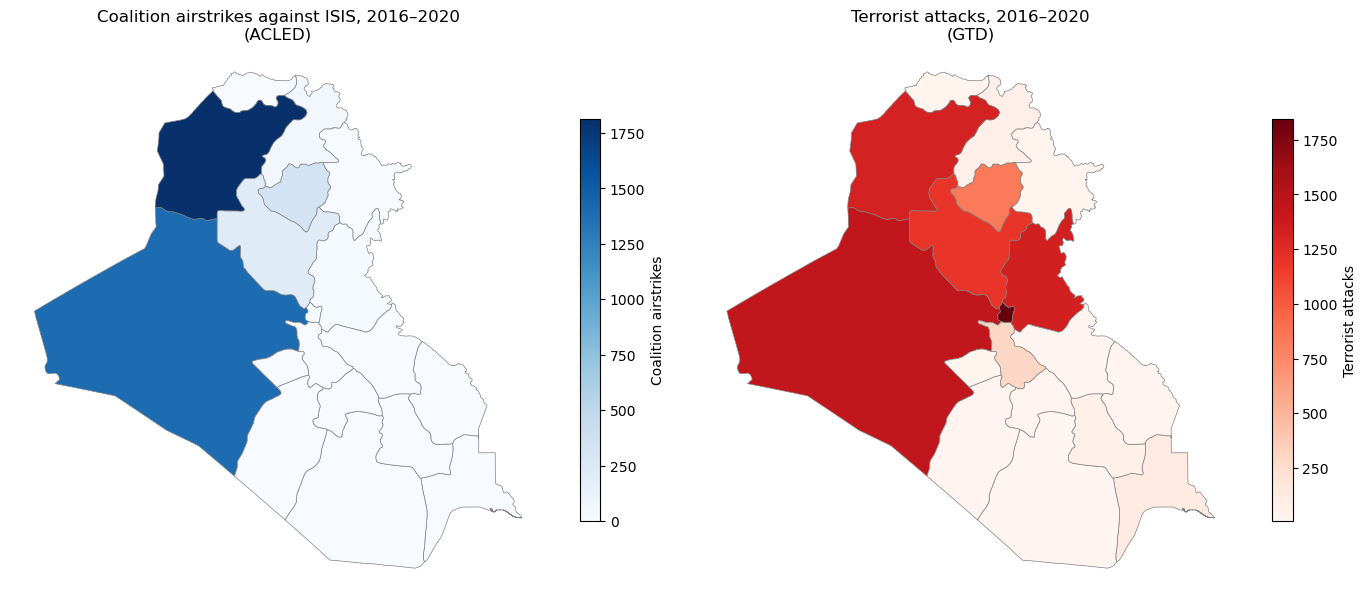

In [7]:
# NOTE: requires geopandas and the GADM Iraq level-1 shapefile in
# gadm41_IRQ_shp/ (download from https://gadm.org/download_country.html).
import geopandas as gpd

iraq = gpd.read_file("gadm41_IRQ_shp/gadm41_IRQ_1.shp")

gadm_to_panel = {
    'Al-Anbar':'Al Anbar','Al-Basrah':'Basra','Al-Muthannia':'Muthanna',
    'Al-Qadisiyah':'Al Qadisiyah','An-Najaf':'Najaf','Arbil':'Arbil',
    'As-Sulaymaniyah':'Sulaymaniyah',"At-Ta'mim":'Kirkuk','Babil':'Babil',
    'Baghdad':'Baghdad','Dhi-Qar':'Dhi Qar','Dihok':'Dihok','Diyala':'Diyala',
    "Karbala'":'Karbala','Maysan':'Maysan','Ninawa':'Nineveh',
    'Sala ad-Din':'Saladin','Wasit':'Wasit',
}
iraq['province'] = iraq['NAME_1'].map(gadm_to_panel)
iraq['strikes'] = iraq['province'].map(panel.groupby('province')['n_strikes'].sum()).fillna(0)
iraq['attacks'] = iraq['province'].map(panel.groupby('province')['n_attacks'].sum()).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
iraq.plot(column='strikes', cmap='Blues', linewidth=0.5, edgecolor='grey',
          legend=True, ax=axes[0], legend_kwds={'label':'Coalition airstrikes','shrink':0.6})
axes[0].set_title('Coalition airstrikes against ISIS, 2016\u20132020\n(ACLED)'); axes[0].axis('off')
iraq.plot(column='attacks', cmap='Reds', linewidth=0.5, edgecolor='grey',
          legend=True, ax=axes[1], legend_kwds={'label':'Terrorist attacks','shrink':0.6})
axes[1].set_title('Terrorist attacks, 2016\u20132020\n(GTD)'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('figures/choropleth_strikes_attacks.png', dpi=300, bbox_inches='tight')
plt.show()

## The campaign over time

Monthly strike and attack counts. Strikes peak early (the 2016–17 push to
retake territory) then taper; attacks follow a broadly parallel decline. The
lead–lag relationship is what the distributed-lag model quantifies.

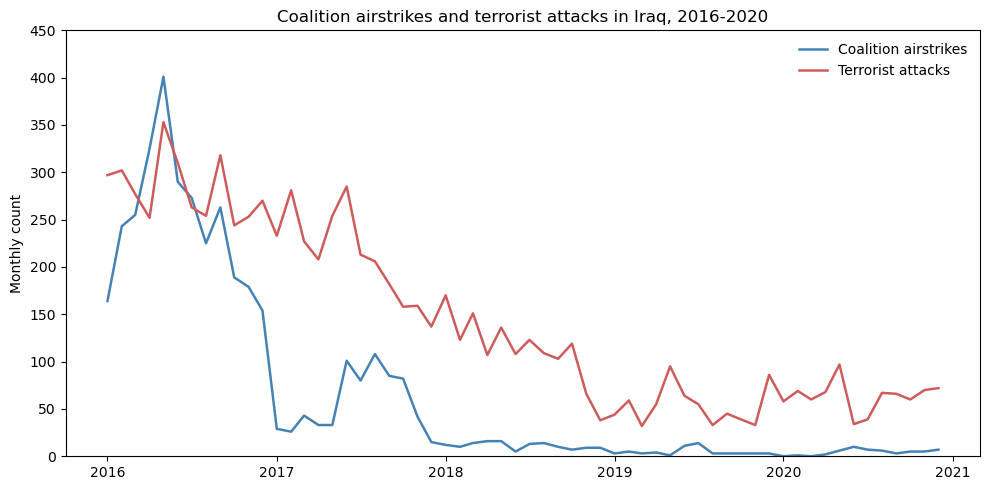

In [8]:
monthly = panel.groupby('year_month').agg(
    strikes=('n_strikes', 'sum'),
    attacks=('n_attacks', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly['year_month'], monthly['strikes'], color='steelblue', lw=1.8, label='Coalition airstrikes')
ax.plot(monthly['year_month'], monthly['attacks'], color='indianred', lw=1.8, label='Terrorist attacks')
ax.set_ylim(0, 450); ax.set_ylabel('Monthly count')
ax.legend(loc='upper right', frameon=False)
ax.set_title('Coalition airstrikes and terrorist attacks in Iraq, 2016-2020')
plt.tight_layout()
plt.savefig('figures/timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

## H1 & H2 lag profiles (12-month)

Coefficient on each monthly lag of (log) strikes. **Left — H1:** effect on
attack *frequency* is largely positive (grievance / retaliation).
**Right — H2:** effect on attack *success rate* trends negative (capacity
degradation).

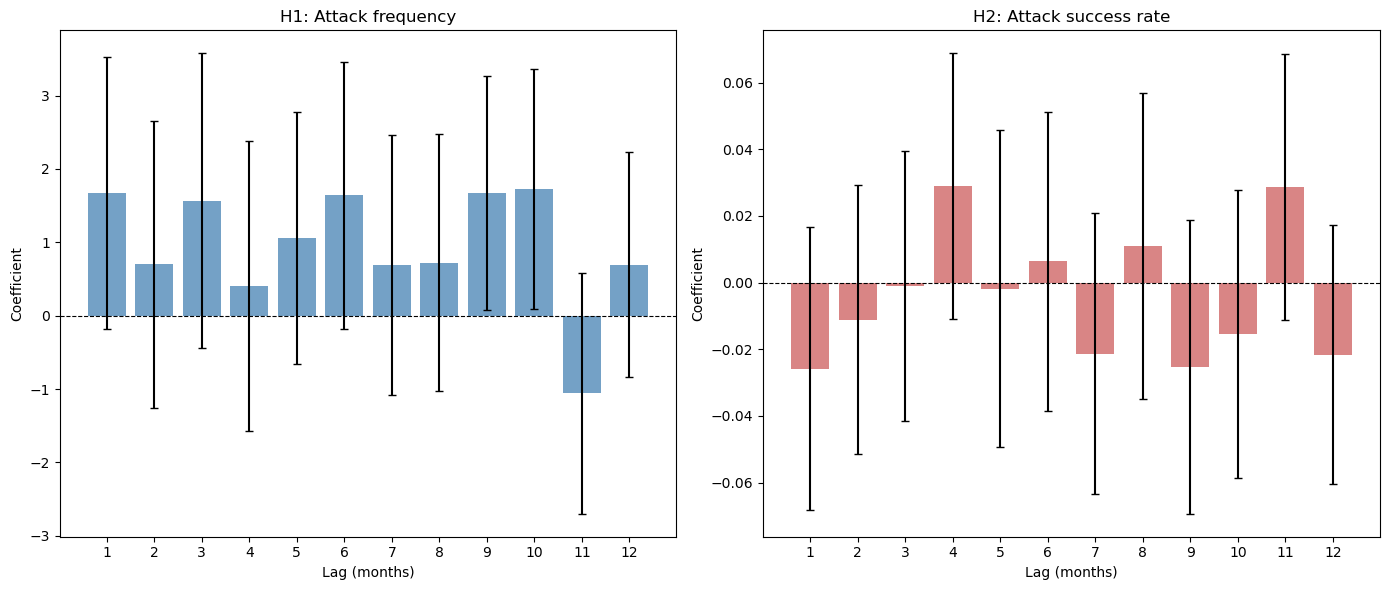

In [9]:
lags = range(1, 13)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, res, col, title in [
    (axes[0], h1_12_result, 'steelblue', 'H1: Attack frequency'),
    (axes[1], h2_12, 'indianred', 'H2: Attack success rate')]:
    b = [res.params[f'log_strikes_lag{k}'] for k in lags]
    ci = res.conf_int()
    lo = [b[i] - ci.loc[f'log_strikes_lag{k}', 'lower'] for i, k in enumerate(lags)]
    hi = [ci.loc[f'log_strikes_lag{k}', 'upper'] - b[i] for i, k in enumerate(lags)]
    ax.bar(lags, b, color=col, alpha=0.75, zorder=2)
    ax.errorbar(lags, b, yerr=[lo, hi], fmt='none', color='black', capsize=3, zorder=3)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Lag (months)'); ax.set_ylabel('Coefficient')
    ax.set_title(title); ax.set_xticks(list(lags))

plt.tight_layout()
plt.savefig('figures/lag_profiles_h1_h2.png', dpi=300, bbox_inches='tight')
plt.show()

## Cumulative effects

The same two models as running cumulative sums with 95% bands — how the total
effect of a strike accumulates over the following year.

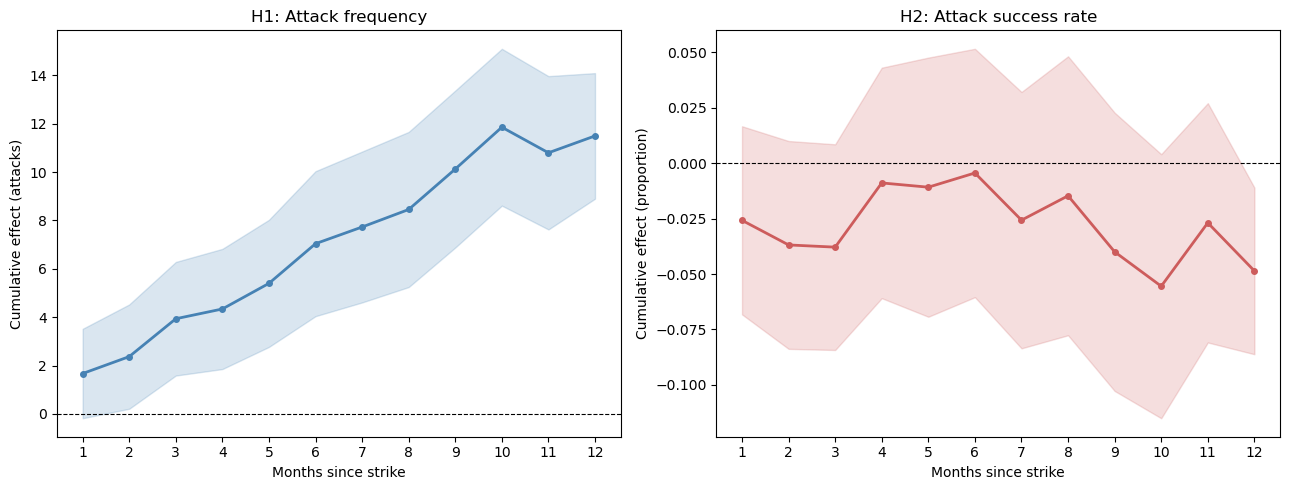

In [10]:
lags = [f'log_strikes_lag{k}' for k in range(1,13)]

def cum_path(res):
    V = res.cov.loc[lags, lags].values
    cum, se = [], []
    for j in range(1, 13):
        w = np.zeros(12); w[:j] = 1
        cum.append(sum(res.params[lags[i]] for i in range(j)))
        se.append(np.sqrt(w @ V @ w))
    return np.array(cum), np.array(se)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, res, col, title, ylab in [
    (axes[0], h1_12_result, 'steelblue', 'H1: Attack frequency', 'Cumulative effect (attacks)'),
    (axes[1], h2_12, 'indianred', 'H2: Attack success rate', 'Cumulative effect (proportion)')]:
    c, s = cum_path(res)
    x = np.arange(1, 13)
    ax.plot(x, c, color=col, lw=2, marker='o', ms=4, zorder=3)
    ax.fill_between(x, c - 1.96*s, c + 1.96*s, color=col, alpha=0.2, zorder=2)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Months since strike'); ax.set_ylabel(ylab)
    ax.set_title(title); ax.set_xticks(x)

plt.tight_layout()
plt.savefig('figures/cumulative_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

## Degradation is conditional on intensity

Splitting province-months by accumulated strike exposure: the H2 degradation
effect is significant only **above median exposure** (sustained bombardment).
Below the median it is indistinguishable from zero.

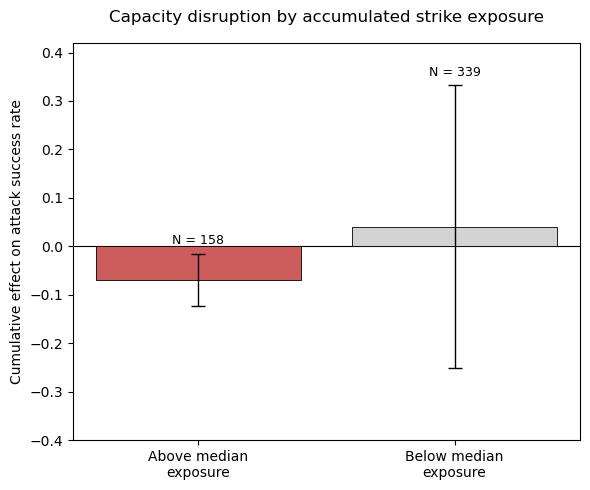

In [11]:
# H2 (success rate) split by accumulated strike exposure: the degradation
# effect is significant only above the median. Values below are the cumulative
# effect / SE / p / N from the above- and below-median 12-lag H2 regressions.
res = [('Above median\nexposure', -0.0693, 0.0274, 0.0115, 158),
       ('Below median\nexposure',  0.0407, 0.1488, 0.7847, 339)]

fig, ax = plt.subplots(figsize=(6,5))
labels = [r[0] for r in res]
vals   = [r[1] for r in res]
errs   = [1.96*r[2] for r in res]
cols   = ['indianred' if r[3] < 0.05 else 'lightgrey' for r in res]

ax.bar(labels, vals, color=cols, edgecolor='black', lw=0.6, zorder=3)
ax.errorbar(labels, vals, yerr=errs, fmt='none', ecolor='black', capsize=5, lw=1, zorder=4)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative effect on attack success rate')
ax.set_ylim(-0.40, 0.42)
ax.set_title('Capacity disruption by accumulated strike exposure', pad=15)
for i, r in enumerate(res):
    ax.text(i, r[1] + (1.96*r[2] + 0.02), f"N = {r[4]}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/intensity_split.png', dpi=300, bbox_inches='tight')
plt.show()